In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

def buscar_archivo(nombre):
    rutas = [os.path.join('csv', nombre), os.path.join('..', 'csv', nombre)]
    for r in rutas:
        if os.path.exists(r):
            return r
    return None

print("Entorno listo.")

Entorno listo.


In [2]:
ruta_b = buscar_archivo('ArchivoB_Adm2025.csv')
ruta_c = buscar_archivo('ArchivoC_Adm2025.csv')

if ruta_b and ruta_c:
    
    df_b = pd.read_csv(ruta_b, sep=';', usecols=['ID_aux', 'GRUPO_DEPENDENCIA'], low_memory=False)
    
    cols_c = [
        'ID_aux', 'CLEC_REG_ACTUAL', 'MATE1_REG_ACTUAL', 
        'MATE2_REG_ACTUAL', 'CIEN_REG_ACTUAL', 'HCSOC_REG_ACTUAL'
    ]
    df_c = pd.read_csv(ruta_c, sep=';', usecols=cols_c, low_memory=False)
    
    df_merged = pd.merge(df_c, df_b, on='ID_aux')
    nombres_dep = {3: 'Municipal', 2: 'Subvencionado', 1: 'Pagado', 4: 'Adm. Delegada', 5: 'SLEP'}
    df_merged['Colegio'] = df_merged['GRUPO_DEPENDENCIA'].map(nombres_dep)

    columnas_puntajes = {
        'CLEC_REG_ACTUAL': 'Lenguaje',
        'MATE1_REG_ACTUAL': 'M1',
        'MATE2_REG_ACTUAL': 'M2',
        'CIEN_REG_ACTUAL': 'Ciencias',
        'HCSOC_REG_ACTUAL': 'Historia'
    }
    
    df_long = pd.melt(df_merged, id_vars=['Colegio'], 
                      value_vars=list(columnas_puntajes.keys()),
                      var_name='Prueba', value_name='Puntaje')
    
    df_long['Prueba'] = df_long['Prueba'].map(columnas_puntajes)
    
    df_final = df_long[df_long['Puntaje'] > 0].dropna()
    
    print(f"Base de datos integrada. Registros procesados: {len(df_final)}")
else:
    print("Archivos no encontrados.")

Base de datos integrada. Registros procesados: 899968


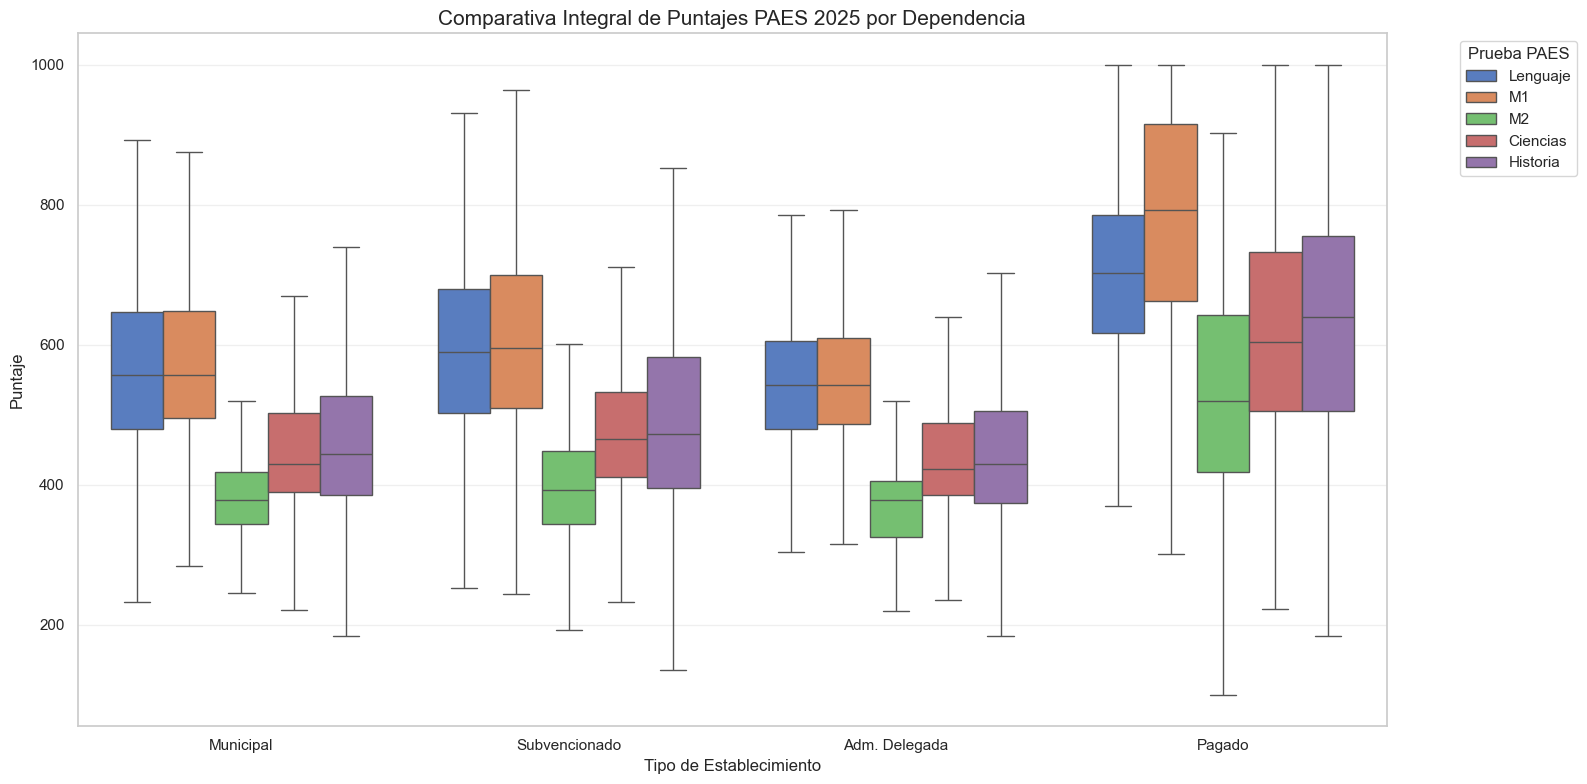

In [3]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=df_final, 
    x='Colegio', 
    y='Puntaje', 
    hue='Prueba', 
    palette='muted',
    showfliers=False
)

plt.title('Comparativa Integral de Puntajes PAES 2025 por Dependencia', fontsize=15)
plt.xlabel('Tipo de Establecimiento')
plt.ylabel('Puntaje')
plt.legend(title='Prueba PAES', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()